Test of the Wagner strain term.

Battini et al. (2002a), Example 7.4


In [ ]:
import xara
from shps.shapes import Rectangle
import matplotlib.pyplot as plt

In [2]:
#<hide>
import thesis

In [ ]:
E = 2.1e6 # MPa
v = 0.33 #0.5*E/G - 1
G = 0.5*E/(1+v) # 787500

material = xara.MultiaxialMaterial("ElasticIsotropic", E=E, nu=v)

In [ ]:

L  = 50
d  = 10
b  = .5
#   L = 1e3
#   d = 200
#   b = 10

#   EI = d**3*b/12 * 2.1e6
#   EI = E*0.85976
shape = Rectangle(d=d, b=b, mesh_scale=1/50, material=material)

GJ = G*(
        (d/2)*(b/2)**3 *(16/3 - 3.36*b/d*(1 - (b/d)**4/12))
        )
GJ = G*0.411 #*0.40433# *0.4824 #
EI = 0.33333333333*2*GJ*L**2
print(shape.summary())

In [ ]:
def create_cantilever(shape, element, trace):

    L  = 50
    ne = 20 # 20

    model = xara.Model(ndm=3, ndf=6)

    model.material(material)

    section = xara.FrameSection("MultiaxialFiber", shape, wagner=True)

    model.section(section)

    model.geomTransf("Linear", 1, (0,0,1))

    model.node(0, (0,0,0))
    for i in range(ne):
        model.node(i+1, ((i+1)*L/ne, 0, 0))
        model.element(element, i+1, (i, i+1), section=section, transform=1)

    model.fix(0,  (1,1,1,  1,1,1))
    return model

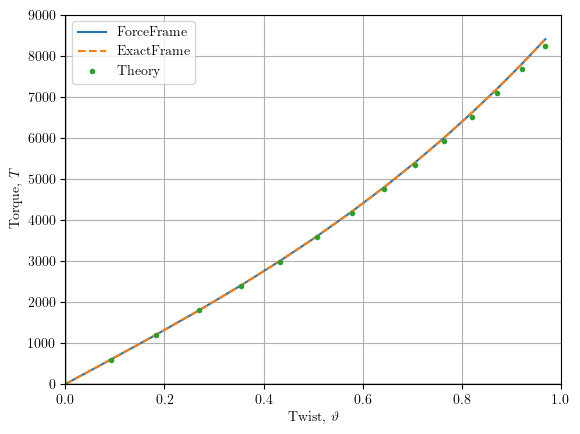

In [ ]:
fig, ax = plt.subplots()
lines = iter(["-", "--", ":"])
ax.grid(True)

for element in ["ForceFrame", "ExactFrame"]:

    model = create_cantilever(shape,
                    trace=None,
                    element = element
                )
    end = len(model.getNodeTags()) - 1

    # Apply torsional moment
    nsteps =  15
    Mmax   = 9e3
    model.pattern("Plain", 1, "Linear")
    model.load(end, (0,0,0,  1,0,0), pattern=1)

    model.system('Umfpack')
    model.integrator("LoadControl", Mmax/nsteps)
    model.test("Energy",1e-16,10,0)
#   model.test('NormUnbalance',1e-6,10,1)
    model.algorithm("Newton")
    model.analysis("Static")

    u = []
    P = []
    while model.getTime() < Mmax:
        u.append(model.nodeDisp(end, 4))
        P.append(model.getTime())
        if model.analyze(1) != 0:
            print(f"Failed at time = {model.getTime()}")
            break

    ax.plot(u, P, label=element, linestyle=next(lines))

ax.set_xlabel(r"Twist, $\vartheta$")
ax.set_ylabel("Torque, $T$")
ax.set_xlim([0,    1])
ax.set_ylim([0, Mmax])
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.plot(u, [GJ*ui/L + 0.5*EI*(ui/L)**3 for ui in u], ".", label="Theory")
ax.legend();

# plt.savefig("img/0015-twist.png", dpi=600)
